# Laboratorio 2 — Deep Learning: Series de Tiempo

El código de preparación de datos, entrenamiento y tuneo está en los archivos [datos_comunes.py](datos_comunes.py), [Modelos.ipynb](Modelos.ipynb) para el Ejercicio 1 y [Catch22.ipynb](Catch22.ipynb) para el Ejercicio 2. Aquí se cargan los resultados ya generados en la carpeta resultados y se comentan.

Todo el ejercicio reutiliza exactamente el mismo train y test del Laboratorio 1. Se filtró a viajeros tipo Turista y Excursionista, que son categorías comparables en todo el periodo 2009 a 2026, y se usó la misma partición cronológica 70/30: 147 meses de entrenamiento y 63 meses de prueba.

In [1]:
import pandas as pd
from IPython.display import Image, display
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
R = "resultados"


## Ejercicio 1 — Modelos LSTM

### 1.1 Series y conjuntos utilizados

Se trabajaron dos series del Laboratorio 1: el total mensual de viajeros, que es la serie obligatoria, y los viajeros por vía Aérea, la categoría de mayor volumen después del total. Se descartó la vía Marítima porque más del 30% de sus meses son cero, lo que la vuelve degenerada para forecasting. Ambas series usan el mismo train y test que sus contrapartes del Laboratorio 1: 147 meses de entrenamiento, de enero 2009 a marzo 2021, y 63 meses de prueba, de abril 2021 a junio 2026.

In [2]:
from datos_comunes import cargar_series
series_train, series_test, labels = cargar_series()
for n in ["total", "via_aerea"]:
    print(f"{n:12s} train={len(series_train[n])}  test={len(series_test[n])}  {labels[n]}")

total        train=147  test=63  Total mensual de viajeros (Turista+Excursionista)
via_aerea    train=147  test=63  Viajeros por vía Aérea


### 1.2 Modelos y tuneo de parámetros

Por cada serie se probaron dos arquitecturas. 
- El modelo 1 es un LSTM simple: una capa LSTM seguida de una capa densa de salida, con un grid de tuneo sobre las unidades, 32 o 64, y la tasa de aprendizaje, 0.001 o 0.01. 
- El modelo 2 es un LSTM con Dropout: una capa LSTM, una capa de Dropout para regularización y la capa densa de salida, con un grid de tuneo sobre las unidades, 32 o 64, y el dropout, 0.1 o 0.3.

La ventana de entrada fue de 12 meses. La selección del mejor config de cada familia se hizo con un recorte de validación tomado de los últimos meses del train. El ganador de cada familia se reentrenó luego con todo el train y se evaluó en test, y ese resultado es el que se reporta en el punto 1.3.

In [3]:
grid = pd.read_csv(f"{R}/ej1_grid.csv")
grid

,serie,familia,units,learning_rate,dropout,val_MAE,val_RMSE
0,total,Modelo 1 (LSTM simple),32,0.001,0.0,0.237890,0.278700
1,total,Modelo 1 (LSTM simple),32,0.010,0.0,0.175577,0.237933
2,total,Modelo 1 (LSTM simple),64,0.001,0.0,0.227390,0.292812
3,total,Modelo 1 (LSTM simple),64,0.010,0.0,0.172466,0.234944
4,total,Modelo 2 (LSTM + Dropout),32,0.001,0.1,0.247876,0.313928
5,total,Modelo 2 (LSTM + Dropout),32,0.001,0.3,0.208755,0.274122
6,total,Modelo 2 (LSTM + Dropout),64,0.001,0.1,0.227837,0.287373
7,total,Modelo 2 (LSTM + Dropout),64,0.001,0.3,0.218454,0.283830
8,via_aerea,Modelo 1 (LSTM simple),32,0.001,0.0,0.240223,0.320428
9,via_aerea,Modelo 1 (LSTM simple),32,0.010,0.0,0.187356,0.248182


### 1.3 Mejor modelo y predicción

La siguiente tabla muestra las métricas en el conjunto de prueba, en la escala original de viajeros por mes, para los dos finalistas de cada serie. La columna es_mejor marca con True el modelo usado para predecir.

In [4]:
finales = pd.read_csv(f"{R}/ej1_finales.csv")
finales

,serie,familia,units,learning_rate,dropout,test_MAE,test_RMSE,es_mejor
0,total,Modelo 1 (LSTM simple),64,0.010,0.0,35687.197334,46499.837002,True
1,total,Modelo 2 (LSTM + Dropout),32,0.001,0.3,39388.643082,50616.310652,False
2,via_aerea,Modelo 1 (LSTM simple),32,0.010,0.0,13939.921978,18115.275391,True
3,via_aerea,Modelo 2 (LSTM + Dropout),32,0.001,0.3,15745.084614,19451.871519,False


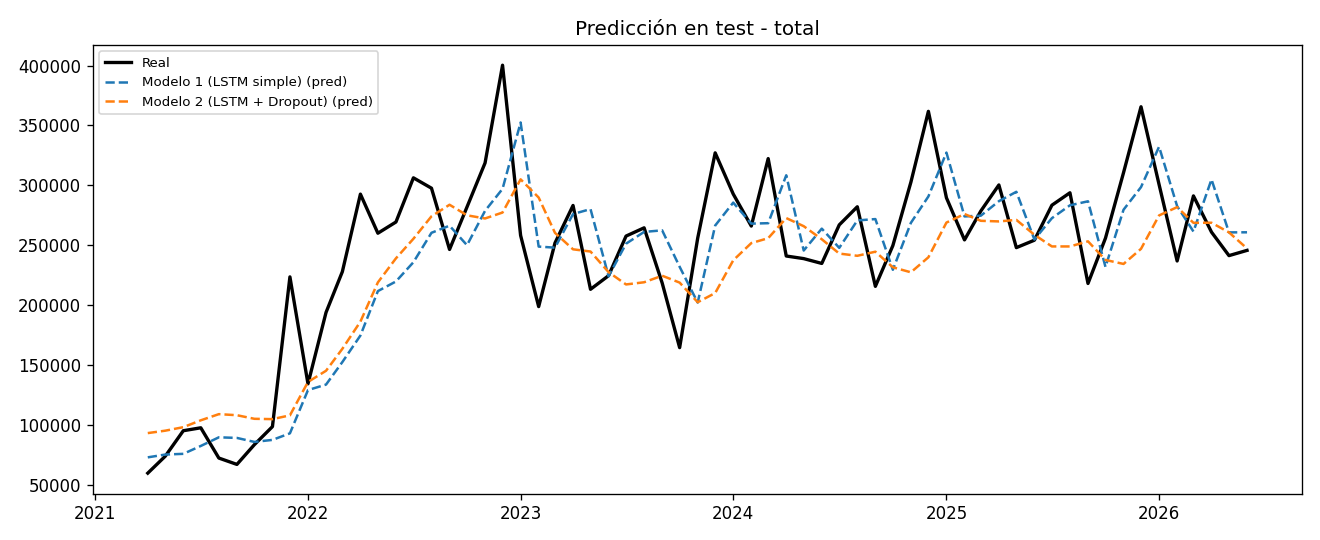

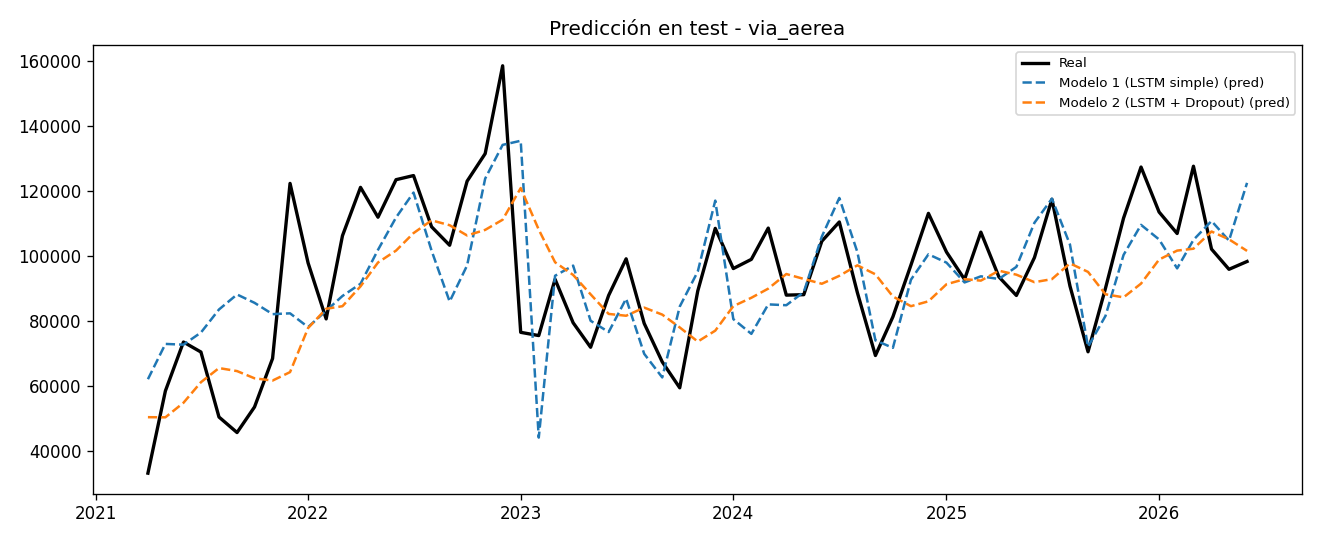

In [5]:
display(Image(filename=f"{R}/ej1_pred_total.png"))
display(Image(filename=f"{R}/ej1_pred_via_aerea.png"))

El mejor modelo en ambas series resultó ser el LSTM simple, con 64 unidades y tasa de aprendizaje 0.01 en la serie total, y 32 unidades y tasa de aprendizaje 0.01 en vía Aérea. En los dos casos quedó levemente por encima de la variante con Dropout. Con una serie de solo alrededor de 150 meses de entrenamiento, el dropout no aporta. Más bien resta capacidad al modelo sin que haga falta esa regularización adicional.

### 1.4 ¿Cuál predijo mejor? ¿Son mejores que los modelos del laboratorio pasado?

Para que la comparación sea justa, los modelos clásicos del Laboratorio 1, que son ARIMA, Prophet, Holt-Winters y suavizamiento exponencial simple, se recalcularon sobre el mismo train y test usado aquí. 

In [6]:
clasicos = pd.read_csv(f"{R}/ej1_clasicos.csv")
clasicos

,serie,modelo,MAE,RMSE
0,total,Prophet,132304.567817,139548.877439
1,total,Holt-Winters,134374.813415,146605.600321
2,total,Suavizamiento exponencial simple,165370.149181,180595.742029
3,total,"ARIMA(2, 0, 0)x(1, 0, 1, 12)",183941.807170,198149.819240
4,via_aerea,Holt-Winters,25453.982590,30455.532725
5,via_aerea,Suavizamiento exponencial simple,36970.595572,42141.220228
6,via_aerea,Prophet,41300.514107,45687.741327
7,via_aerea,"ARIMA(3, 0, 2)x(1, 0, 1, 12)",73002.349083,76874.847964


In [7]:
resumen = []
for n in ["total", "via_aerea"]:
    mejor_lstm = finales[(finales.serie == n) & (finales.es_mejor)].iloc[0]
    mejor_clasico = clasicos[clasicos.serie == n].iloc[0]
    resumen.append({
        "serie": n,
        "mejor_LSTM": mejor_lstm.familia, "LSTM_MAE": round(mejor_lstm.test_MAE), "LSTM_RMSE": round(mejor_lstm.test_RMSE),
        "mejor_clasico": mejor_clasico.modelo, "clasico_MAE": round(mejor_clasico.MAE), "clasico_RMSE": round(mejor_clasico.RMSE),
        "mejora_RMSE_%": round(100 * (1 - mejor_lstm.test_RMSE / mejor_clasico.RMSE), 1),
    })
pd.DataFrame(resumen)

,serie,mejor_LSTM,LSTM_MAE,LSTM_RMSE,mejor_clasico,clasico_MAE,clasico_RMSE,mejora_RMSE_%
0,total,Modelo 1 (LSTM simple),35687,46500,Prophet,132305,139549,66.7
1,via_aerea,Modelo 1 (LSTM simple),13940,18115,Holt-Winters,25454,30456,40.5


El LSTM predijo claramente mejor que el mejor modelo clásico en las dos series. En total, el LSTM tuvo un RMSE de aproximadamente 46,500 frente a un RMSE de aproximadamente 139,549 de Prophet, una mejora de casi 67%. En vía Aérea, el LSTM tuvo un RMSE de aproximadamente 18,115 frente a 30,456 de Holt-Winters, una mejora de alrededor de 40%.

Lo determinamos comparando MAE y RMSE sobre el mismo conjunto de prueba de 63 meses, de abril 2021 a junio 2026, para todos los modelos. Es una comparación directa, sin ajustes de por medio. La razón de la diferencia se ve en las gráficas de predicción. El tramo de prueba cae justo en la recuperación pospandemia, un quiebre de nivel fuerte y no lineal. Los modelos clásicos fueron entrenados con datos previos a ese quiebre y extrapolan mal una dinámica que nunca vieron. El LSTM, al trabajar sobre la serie escalada y con ventanas de 12 meses, se adapta algo mejor a esa no linealidad, aunque igual se nota un rezago frente a los picos más abruptos.

## Ejercicio 2 — catch22

### 2.1 ¿Qué es catch22 y por qué es importante?

catch22 es un conjunto de 22 características estadísticas para series de tiempo, seleccionadas del proyecto hctsa de Fulcher, Little y Jones, que originalmente calcula más de 7,000 características. Se eligieron esas 22 porque conservan casi todo el poder de clasificación del conjunto completo, cubriendo aspectos como distribución, autocorrelación, entropía y valores atípicos, sin redundancia entre ellas. 

Es importante porque permite comparar la forma de muchas series de tiempo de manera estandarizada, rápida y reproducible, sin diseñar características a mano para cada caso.

### 2.2 – 2.3 Extracción de características y matriz series × características

In [8]:
features = pd.read_csv(f"{R}/ej2_features.csv", index_col=0)
features.round(3)

,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,CO_Embed2_Dist_tau_d_expfit_meandiff,IN_AutoMutualInfoStats_40_gaussian_fmmi,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
serie,,,,,,,,,,,,,,,,,,,,,,
total,0.083,0.342,8.965,3.0,0.352,-0.062,0.933,30.0,0.014,11.0,0.318,2.0,0.056,0.210,0.324,0.820,6.0,1.852,0.833,0.857,0.123,0.626
via_aerea,-0.398,-0.115,6.591,10.0,0.206,-0.163,0.957,34.0,0.010,11.0,0.210,9.0,0.071,0.186,0.324,0.758,5.0,2.001,0.857,0.857,0.172,0.739
via_terrestre,0.277,-0.193,9.573,2.0,0.484,-0.025,0.933,29.0,0.014,3.0,0.336,1.0,0.056,0.219,0.329,0.818,6.0,1.782,0.833,0.857,0.098,0.616
via_maritima,-0.577,-0.729,41.892,6.0,0.667,-0.040,0.450,96.0,0.074,7.0,0.413,1.0,0.014,-0.552,0.462,0.945,4.0,1.205,0.167,0.786,0.025,0.323
region1,0.391,0.128,8.866,3.0,0.400,-0.065,0.919,42.0,0.014,7.0,0.320,2.0,0.056,0.171,0.324,0.815,6.0,1.833,0.786,0.857,0.123,0.635
region2,0.311,-0.239,9.077,2.0,0.271,-0.012,0.943,12.0,0.036,3.0,0.277,1.0,0.038,0.829,0.324,0.740,5.0,2.053,0.167,0.738,0.098,0.722
region3,0.268,0.008,4.448,2.0,0.348,0.084,0.943,8.0,0.014,8.0,0.230,1.0,0.059,0.819,0.333,0.762,6.0,2.055,0.143,0.738,0.172,0.783


### 2.4 Estandarización

In [9]:
features_std = pd.read_csv(f"{R}/ej2_features_std.csv", index_col=0)
features_std.round(2)

,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,CO_Embed2_Dist_tau_d_expfit_meandiff,IN_AutoMutualInfoStats_40_gaussian_fmmi,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
serie,,,,,,,,,,,,,,,,,,,,,,
total,0.09,1.46,-0.32,-0.36,-0.27,-0.32,0.38,-0.22,-0.53,1.27,0.28,-0.16,0.33,-0.14,-0.46,0.18,0.78,0.09,0.88,0.83,0.15,-0.06
via_aerea,-1.27,-0.00,-0.51,2.16,-1.31,-1.79,0.52,-0.07,-0.69,1.27,-1.42,2.42,1.26,-0.19,-0.46,-0.79,-0.59,0.64,0.95,0.83,1.20,0.74
via_terrestre,0.64,-0.25,-0.27,-0.72,0.67,0.23,0.38,-0.25,-0.53,-1.36,0.55,-0.53,0.33,-0.11,-0.36,0.15,0.78,-0.16,0.88,0.83,-0.37,-0.14
via_maritima,-1.77,-1.97,2.43,0.72,1.98,-0.00,-2.44,2.23,2.27,-0.05,1.77,-0.53,-2.09,-1.90,2.44,2.15,-1.96,-2.27,-1.13,-0.51,-1.95,-2.22
region1,0.96,0.78,-0.33,-0.36,0.07,-0.36,0.30,0.23,-0.53,-0.05,0.30,-0.16,0.33,-0.22,-0.46,0.11,0.78,0.03,0.74,0.83,0.15,-0.00
region2,0.74,-0.40,-0.31,-0.72,-0.85,0.42,0.44,-0.89,0.52,-1.36,-0.37,-0.53,-0.68,1.29,-0.46,-1.07,-0.59,0.83,-1.13,-1.41,-0.37,0.62
region3,0.61,0.39,-0.69,-0.72,-0.30,1.82,0.44,-1.03,-0.52,0.28,-1.11,-0.53,0.52,1.27,-0.26,-0.73,0.78,0.84,-1.20,-1.41,1.20,1.06


### 2.5 PCA, clustering, heatmap, correlación y distancias

In [10]:
pca = pd.read_csv(f"{R}/ej2_pca.csv", index_col=0)
pca.round(2)

,PC1,PC2
serie,,
total,-1.23,-0.96
via_aerea,-2.29,-4.43
via_terrestre,-0.31,0.77
via_maritima,8.61,-0.21
region1,-0.94,-0.29
region2,-1.10,2.71
region3,-2.73,2.40


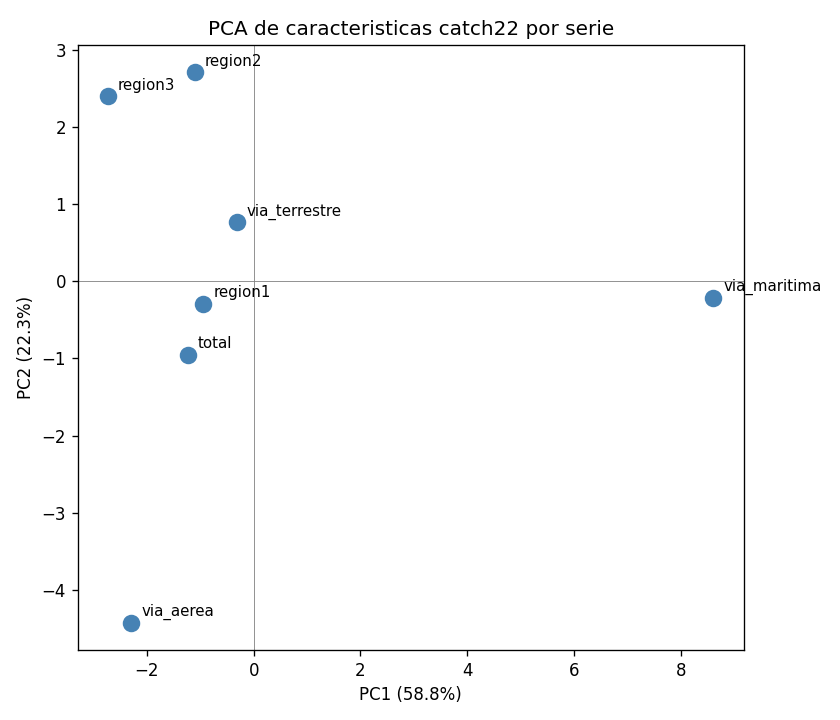

In [11]:
display(Image(filename=f"{R}/ej2_pca.png"))

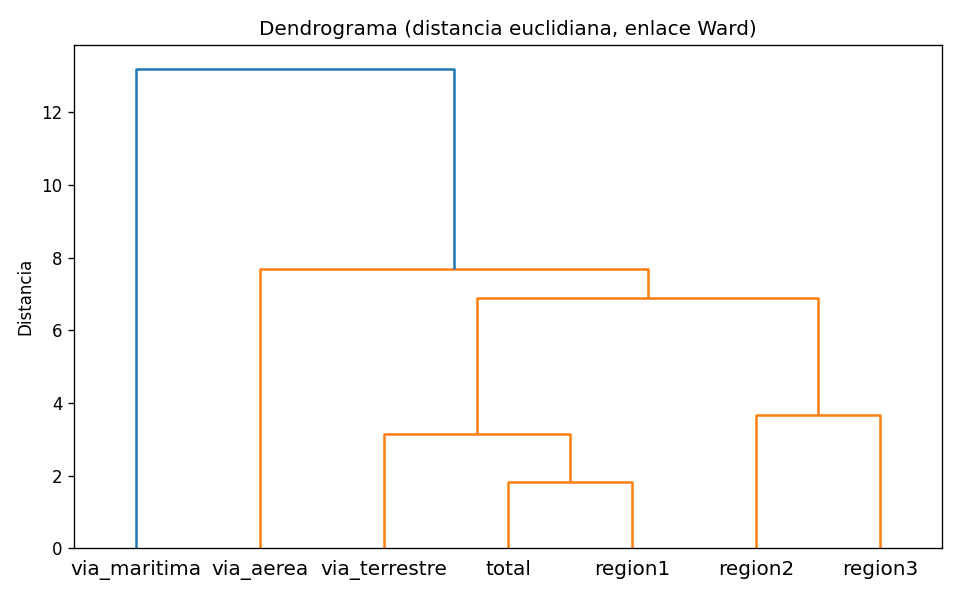

,serie,cluster
0,total,0
1,via_aerea,0
2,via_terrestre,0
3,via_maritima,1
4,region1,0
5,region2,0
6,region3,0


In [12]:
display(Image(filename=f"{R}/ej2_dendrograma.png"))
clusters = pd.read_csv(f"{R}/ej2_clusters.csv")
clusters

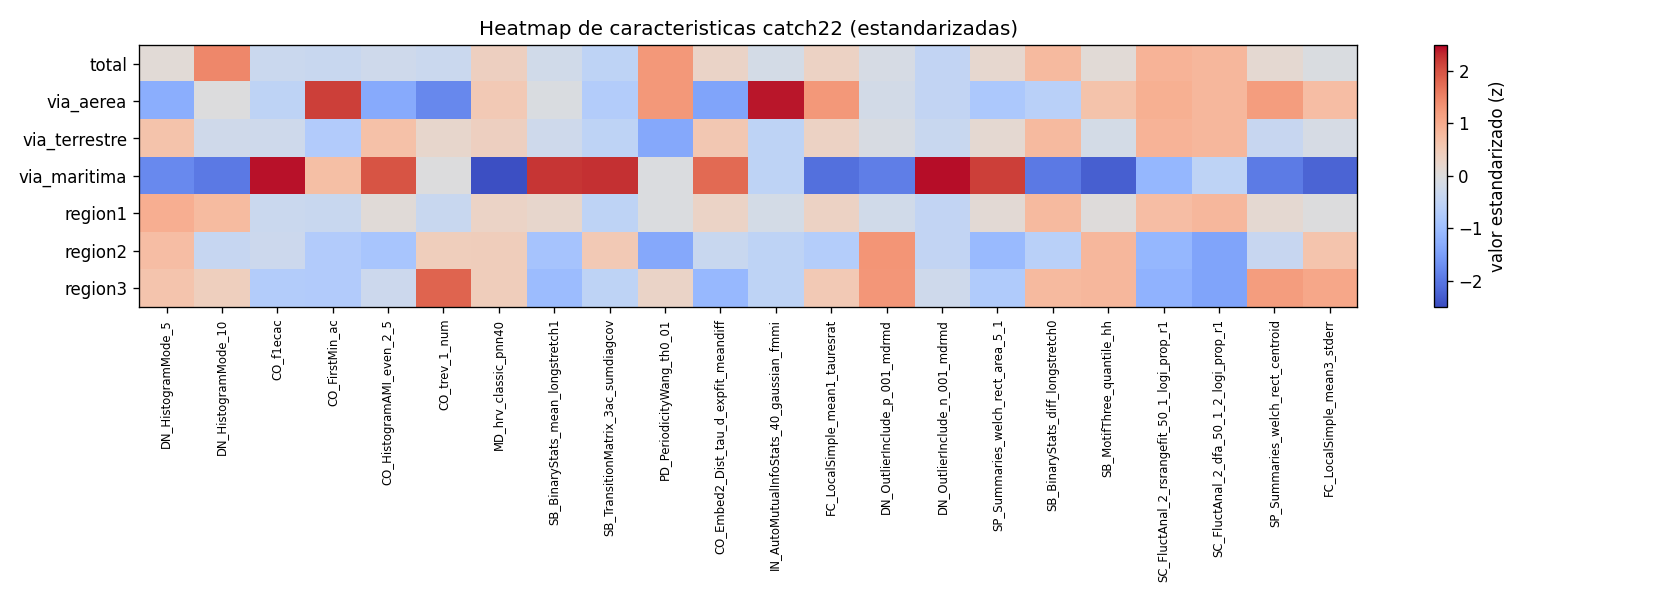

In [13]:
display(Image(filename=f"{R}/ej2_heatmap.png"))

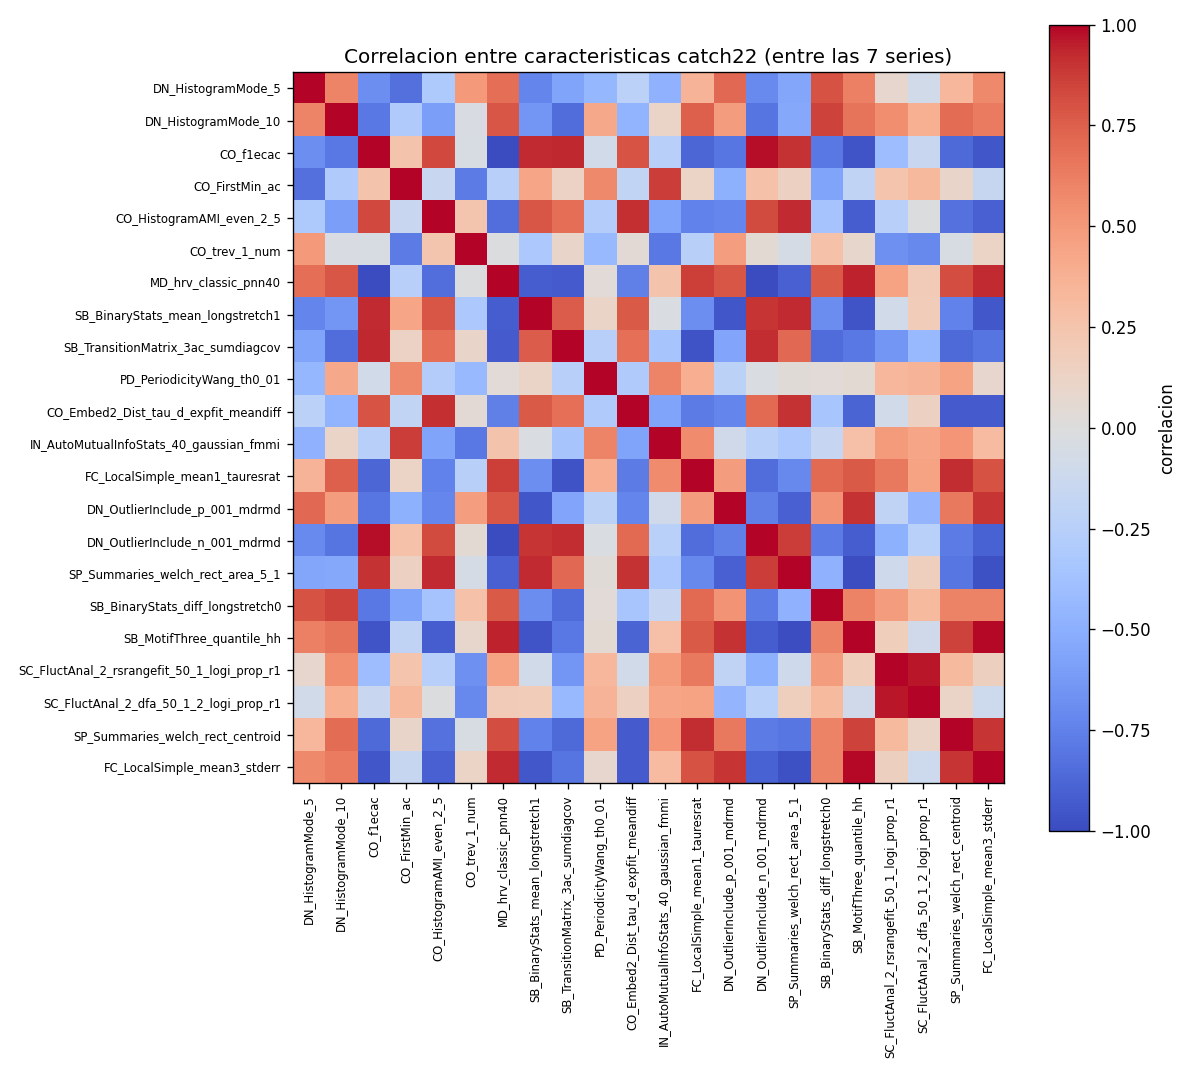

In [14]:
display(Image(filename=f"{R}/ej2_corr.png"))

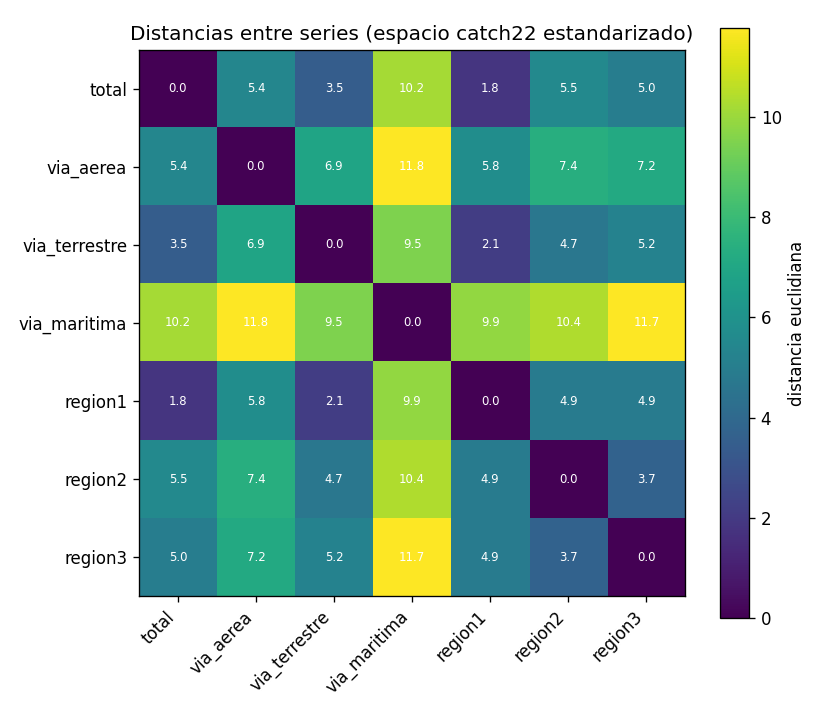

,total,via_aerea,via_terrestre,via_maritima,region1,region2,region3
serie,,,,,,,
total,0.0,5.4,3.5,10.2,1.8,5.5,5.0
via_aerea,5.4,0.0,6.9,11.8,5.8,7.4,7.2
via_terrestre,3.5,6.9,0.0,9.5,2.1,4.7,5.2
via_maritima,10.2,11.8,9.5,0.0,9.9,10.4,11.7
region1,1.8,5.8,2.1,9.9,0.0,4.9,4.9
region2,5.5,7.4,4.7,10.4,4.9,0.0,3.7
region3,5.0,7.2,5.2,11.7,4.9,3.7,0.0


In [15]:
distancias = pd.read_csv(f"{R}/ej2_distancias.csv", index_col=0)
display(Image(filename=f"{R}/ej2_distancias.png"))
distancias.round(1)

### 2.6 Análisis e interpretación

Las siguientes respuestas se apoyan en la tabla de distancias, el PCA y el dendrograma de arriba.

### 2.7 ¿Cuáles series presentan comportamientos más similares?

Total y región 1, América del Centro, son las series más parecidas entre sí, con la distancia más baja de toda la matriz. Vía Terrestre es la siguiente más cercana a ambas. Tiene sentido, porque la mayoría del turismo hacia y desde Guatemala se mueve por tierra dentro de la región.

### 2.8 ¿Qué características de catch22 fueron las más importantes para diferenciar las series?

De las 22 características de catch22, dos resultaron ser las que más marcan diferencias entre las series. 

- La primera que mide qué tan rápido se pierde la memoria y que tan rápido decae la autocorrelación de la serie.

Esta fue importante ya que es la que deja a vía Marítima tan aparte del resto, porque su comportamiento es mucho más lento y estable que el de las demás. 

- La segunda que mide la periodicidad y que indica si la serie se ve distinta hacia adelante que hacia atrás en el tiempo. 

Esta segunda característica es la que separa a vía Aérea de región 2 y región 3, mostrando que su forma de moverse en el tiempo es distinta a la de esas dos regiones.

### 2.9 ¿Existen grupos naturales de series?

Sí. El análisis encontró que lo más claro es dividir las series en dos grupos: uno formado solo por vía Marítima, y otro con las seis series restantes, que se comportan de forma mucho más parecida entre sí. 

Dentro de ese grupo grande, si se mira con más detalle, también aparecen subgrupos. Total, región 1 y vía Terrestre quedan juntas, y son las series ligadas al turismo terrestre y regional, con una dinámica más estable. Región 2 y región 3, que son Norteamérica y Europa, forman otro subgrupo, ligado a viajeros que vienen de más lejos y con un comportamiento más volátil. Vía Aérea queda un poco aparte de ambos, por su periodicidad particular.

### 2.10 ¿Las series de una misma categoría tienden a agruparse?

No de forma limpia. Si la categoría explicara la forma de la serie, las tres vías deberían agruparse entre sí y las tres regiones entre sí, pero no es lo que se observa. Las vías están dispersas: vía Terrestre cae junto al total, vía Aérea se aleja por el segundo componente, y vía Marítima es la más distinta de las siete series. Las regiones solo se agrupan parcialmente: región 1 se parece mucho más a total y a vía Terrestre que a región 2 o región 3, mientras que región 2 y región 3 sí forman un subgrupo coherente entre sí.

### 2.11 Serie con comportamiento más atípico

Vía Marítima. Su distancia media al resto es 9.1, muy por encima de la siguiente, que es vía Aérea con 6.3. Esto es consistente con lo que ya se había detectado en el análisis exploratorio del Laboratorio 1, es una serie con más del 30% de sus meses en cero, por lo que ahí se había descartado del análisis de tendencia y estacionalidad por degenerada. 

catch22 sí logra describirla: tiene una autocorrelación extremadamente persistente, con un CO_f1ecac cercano a 42 meses frente a 4 a 10 en las demás series, rachas largas de valores constantes, con SB_BinaryStats_mean_longstretch1 igual a 96, y una variabilidad normal mes a mes muy baja, con MD_hrv_classic_pnn40 de 0.45 frente a 0.9 o más en el resto, salpicada de saltos esporádicos. Es el perfil típico de una serie con largos tramos planos o en cero y picos aislados, muy distinta de las series turísticas regulares y estacionales.

### 2.12 Comparación con el análisis exploratorio: tendencia, estacionalidad, volatilidad, pandemia y autocorrelación

In [16]:
eda = pd.read_csv(f"{R}/ej2_eda_comparativo.csv")
eda

,serie,label,fuerza_tendencia,fuerza_estacionalidad,volatilidad_pct,impacto_pandemia_pct,nota
0,total,Total mensual de viajeros (Turista+Excursionista),0.783473,0.225739,32.738069,-74.353675,NaN
1,via_aerea,Viajeros por vía Aérea,0.706638,0.147637,48.746620,-72.797037,NaN
2,via_terrestre,Viajeros por vía Terrestre,0.818123,0.287647,38.472822,-75.225405,NaN
3,via_maritima,Viajeros por vía Marítima,NaN,NaN,NaN,NaN,serie degenerada (>30% meses en cero)
4,region1,Viajeros por región: América Del Centro,0.791784,0.245073,31.933866,-74.431095,NaN
5,region2,Viajeros por región: América Del Norte,0.637419,0.093924,107.378497,-74.144309,NaN
6,region3,Viajeros por región: Europa,0.716636,0.187690,85.921201,-71.829700,NaN


En general, los agrupamientos de catch22 sí son consistentes con el EDA tradicional.

- En tendencia, total, vía Terrestre y región 1 tienen la fuerza de tendencia más alta y parecida, entre 0.78 y 0.82, justo el subgrupo que catch22 identificó como el más similar entre sí.

- En estacionalidad, ese mismo trío tiene también la mayor fuerza estacional, entre 0.23 y 0.29, coherente con que comparten dinámica.

- En volatilidad, región 2 tiene la volatilidad más alta, 107%, y la menor fuerza de tendencia, 0.64, de las series válidas, lo que coincide con que catch22 la separa del núcleo formado por total, región 1 y vía Terrestre.

- En el impacto de la pandemia, todas las series caen de forma parecida en 2020, entre 72% y 75%, así que este factor no es el que explica las diferencias entre clusters, ya que todas comparten ese golpe casi por igual.

- En la autocorrelación, el resultado es coherente con el CO_f1ecac de catch22: las series normales decaen rápido, algo típico de series estacionales con ruido, mientras que vía Marítima decae muy lento, lo que refleja sus tramos planos.

La única serie que el EDA tradicional no pudo describir, por ser degenerada, es justo la que catch22 señala como más atípica. Ahí catch22 aporta lo que el EDA no pudo.

### 2.13 Al menos tres descubrimientos de catch22 que no eran evidentes en el EDA tradicional

1. Región 1 es, en términos de forma, la serie más parecida al total nacional, con una distancia de 1.8, la menor de toda la matriz, más parecida que cualquiera de las tres vías de ingreso. El EDA por separado no permitía comparar directamente la similitud de forma entre series de categorías distintas, como vía, región y total.

2. Vía Aérea es la segunda serie más atípica del conjunto, no por degeneración de datos como vía Marítima, sino por su periodicidad y reversibilidad temporal en el segundo componente. Es un tipo de asimetría estructural que las métricas de tendencia, estacionalidad y volatilidad del EDA no capturan directamente.

3. Región 2, América del Norte, y región 3, Europa, comparten una firma catch22 muy cercana, con una distancia de 3.7, la segunda más baja después de total y región 1, a pesar de ser mercados geográficamente opuestos. Esto sugiere un patrón común de turismo de larga distancia que el EDA tradicional, al analizarlas por separado, no dejaba ver.

4. catch22 permitió caracterizar cuantitativamente a vía Marítima, con su autocorrelación, sus rachas y su variabilidad, en vez de simplemente descartarla como degenerada, que era el tratamiento que había recibido en el Laboratorio 1.

### 2.14 LSTM con características catch22 vs. mejor LSTM del Ejercicio 1

Se construyó un LSTM adicional para la serie total. En vez de recibir los 12 valores crudos de la ventana, recibe las 22 características catch22 calculadas sobre ventanas rodantes de 12 meses, usando las últimas 3 ventanas consecutivas como secuencia de entrada, para predecir el mes siguiente.

In [17]:
comparacion = pd.read_csv(f"{R}/ej2_lstm_catch22_comparacion.csv")
comparacion

,modelo,MAE,RMSE
0,LSTM (ventana de valores crudos) - mejor de Ej...,35687.197334,46499.837002
1,LSTM + caracteristicas catch22 (rolling),236903.276279,289520.044132


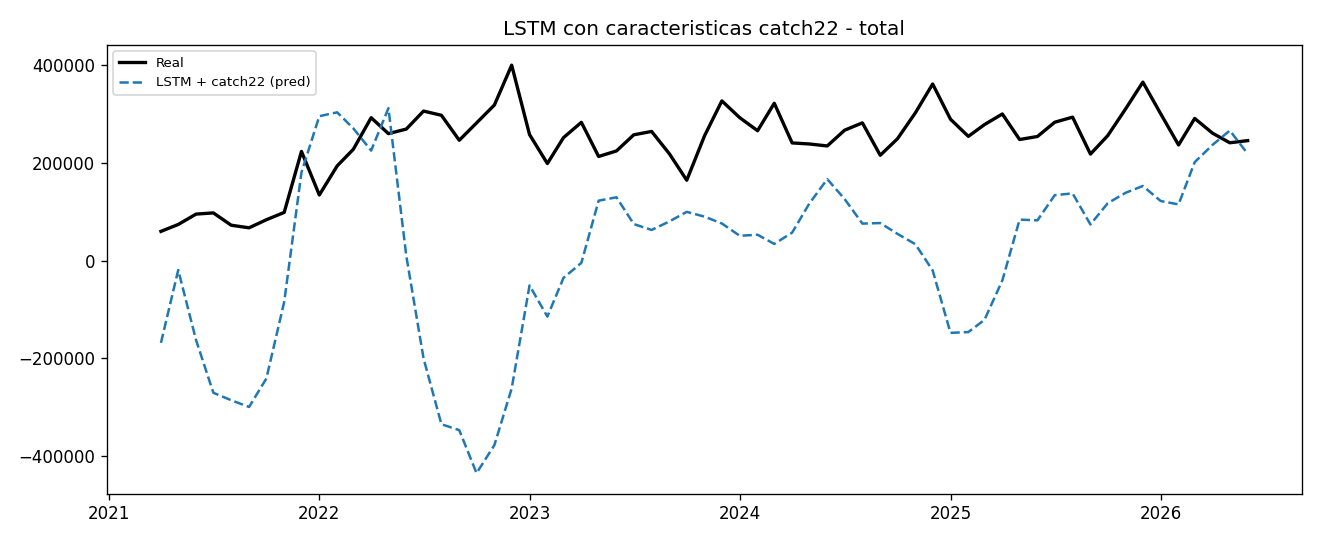

In [18]:
display(Image(filename=f"{R}/ej2_lstm_catch22_pred.png"))

El resultado nos dice que, el LSTM con catch22 predice mucho peor que el LSTM clásico. Su RMSE es de aproximadamente 289,520 frente a 46,500, casi 6 veces peor, y la gráfica muestra que ni siquiera sigue el nivel real de la serie.

Esto tiene una explicación sencilla, catch22 fue diseñado para describir la forma y la dinámica de una ventana, como la autocorrelación, la entropía y la distribución, y varias de sus características son deliberadamente invariantes a escala y nivel. Es decir, descartan a propósito la información de en qué nivel está la serie ahora mismo, que es precisamente lo más importante para predecir el próximo valor. Además, cada vector catch22 resume 12 meses en un solo punto, así que aunque se usen 3 ventanas consecutivas, el modelo ve mucha menos información granular que el LSTM clásico, que ve los 12 valores individuales.

En conclusión, catch22 es una herramienta muy útil para comparar y agrupar series, que es justo lo que se hizo en los puntos 2.2 a 2.13, pero no es un buen insumo para pronosticar el valor puntual siguiente. Para eso, un LSTM sobre los valores crudos de la serie sigue siendo la mejor opción.